In [1]:
!git clone https://github.com/shuvo-iitkgp/heavy-tailed-kmeans.git
%cd heavy-tailed-kmeans


Cloning into 'heavy-tailed-kmeans'...
remote: Enumerating objects: 86, done.
remote: Counting objects: 100% (55/55), done.
remote: Compressing objects: 100% (46/46), done.
remote: Total 86 (delta 12), reused 48 (delta 9), pack-reused 31 (from 1)
Receiving objects: 100% (86/86), 41.70 MiB | 20.03 MiB/s, done.
Resolving deltas: 100% (18/18), done.
/content/heavy-tailed-kmeans



Running experiments for k = 3
  Processing n = 500...
  Processing n = 1000...
  Processing n = 2000...

Running experiments for k = 5
  Processing n = 500...
  Processing n = 1000...
  Processing n = 2000...


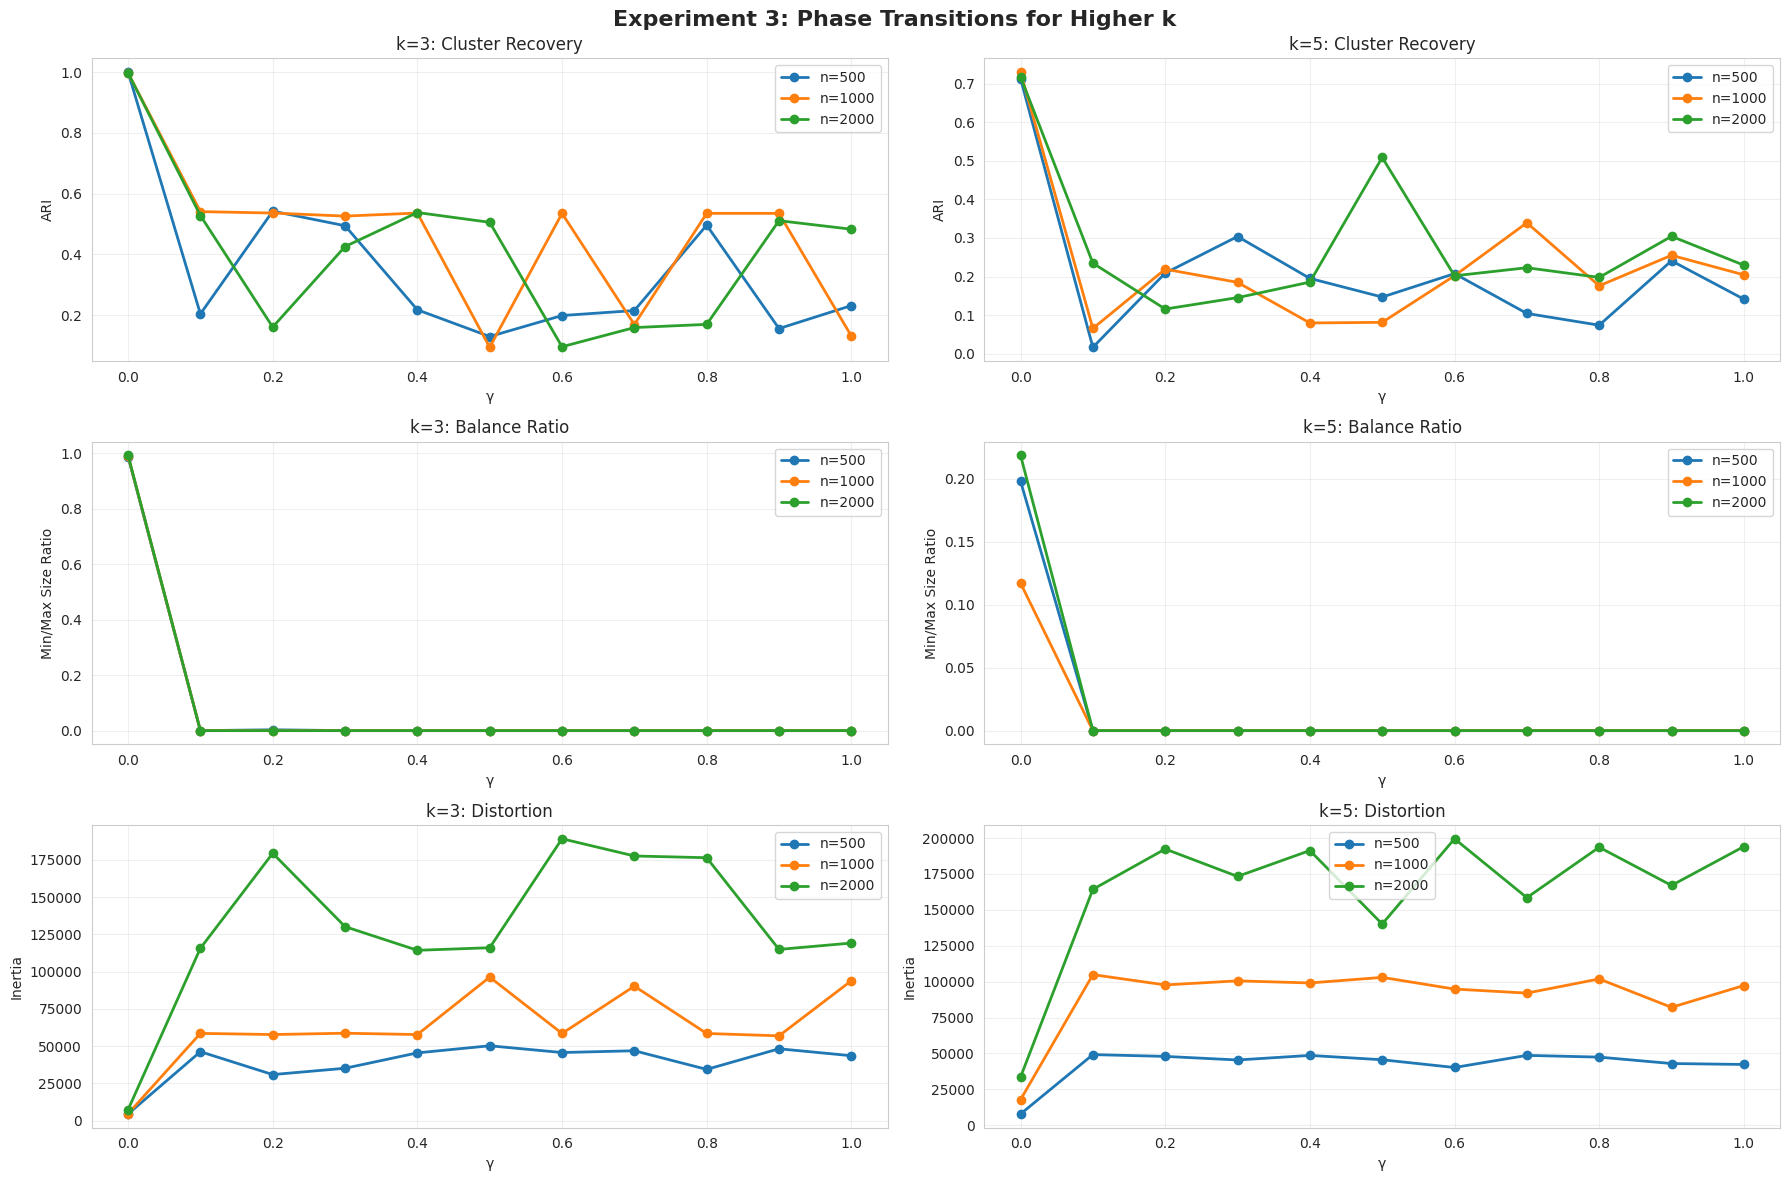


Experiment 3 results saved to: experiment_3_results.csv
Preview:


In [5]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pareto
from sklearn.metrics import adjusted_rand_score

sns.set_style("whitegrid")

def generate_pareto_mixture(n_samples, proportions, centers, pareto_alpha=2.0, noise_std=0.8, dimension=2):
    k = len(proportions)
    cluster_sizes = [int(n_samples * p) for p in proportions]
    cluster_sizes[-1] = n_samples - sum(cluster_sizes[:-1])
    X, y_true = [], []
    for i, (size, center) in enumerate(zip(cluster_sizes, centers)):
        if i == 0:
            radii = pareto.rvs(pareto_alpha, size=size)
            angles = np.random.uniform(0, 2*np.pi, size)
            points = np.column_stack([center[0] + radii * np.cos(angles), center[1] + radii * np.sin(angles)])
        else:
            points = np.random.randn(size, dimension) * noise_std + center
        X.append(points)
        y_true.extend([i] * size)
    X = np.vstack(X)
    y_true = np.array(y_true)
    idx = np.random.permutation(n_samples)
    return X[idx], y_true[idx]


def balanced_kmeans(X, k, gamma, max_iter=100):
    n = len(X)
    target_size = n / k
    centers = X[np.random.choice(n, k, replace=False)]
    labels = np.zeros(n, dtype=int)
    for _ in range(max_iter):
        dists = np.sum((X[:, np.newaxis, :] - centers[np.newaxis, :, :]) ** 2, axis=2)
        cluster_sizes = np.zeros(k)
        for idx in np.argsort(np.min(dists, axis=1)):
            balance_penalty = gamma * (cluster_sizes - target_size) ** 2
            adjusted_dists = dists[idx] + balance_penalty
            labels[idx] = np.argmin(adjusted_dists)
            cluster_sizes[labels[idx]] += 1
        new_centers = np.array([X[labels == j].mean(axis=0) if np.sum(labels == j) > 0 else centers[j] for j in range(k)])
        if np.allclose(centers, new_centers):
            break
        centers = new_centers
    inertia = np.sum([np.sum((X[labels == j] - centers[j]) ** 2) for j in range(k)])
    return labels, centers, inertia


def experiment_higher_k(k_values=[3, 5], n_values=[500, 1000, 2000], gamma_values=None):
    if gamma_values is None:
        gamma_values = np.linspace(0, 1, 11)
    all_results = []
    for k in k_values:
        print(f"\n{'='*60}\nRunning experiments for k = {k}\n{'='*60}")
        for n in n_values:
            print(f"  Processing n = {n}...")
            proportions = [1/k] * k
            angle_step = 2 * np.pi / k
            radius = 10
            centers = [np.array([radius * np.cos(i * angle_step), radius * np.sin(i * angle_step)]) for i in range(k)]
            X, y_true = generate_pareto_mixture(n, proportions, centers)
            for gamma in gamma_values:
                labels, centers_pred, inertia = balanced_kmeans(X, k=k, gamma=gamma)
                ari = adjusted_rand_score(y_true, labels)
                cluster_sizes = [np.sum(labels == i) for i in range(k)]
                min_size = min(cluster_sizes)
                max_size = max(cluster_sizes)
                size_ratio = min_size / max_size if max_size > 0 else 0
                size_std = np.std(cluster_sizes)
                all_results.append({
                    'k': k,
                    'n': n,
                    'gamma': gamma,
                    'ARI': ari,
                    'min_cluster_size': min_size,
                    'max_cluster_size': max_size,
                    'size_ratio': size_ratio,
                    'size_std': size_std,
                    'inertia': inertia
                })
    results_df = pd.DataFrame(all_results)

    fig = plt.figure(figsize=(18, 12))
    for k_idx, k in enumerate(k_values):
        k_data = results_df[results_df['k'] == k]
        ax1 = plt.subplot(3, len(k_values), k_idx + 1)
        for n in n_values:
            n_data = k_data[k_data['n'] == n]
            ax1.plot(n_data['gamma'], n_data['ARI'], 'o-', label=f'n={n}', linewidth=2)
        ax1.set_xlabel('γ')
        ax1.set_ylabel('ARI')
        ax1.set_title(f'k={k}: Cluster Recovery')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        ax2 = plt.subplot(3, len(k_values), len(k_values) + k_idx + 1)
        for n in n_values:
            n_data = k_data[k_data['n'] == n]
            ax2.plot(n_data['gamma'], n_data['size_ratio'], 'o-', label=f'n={n}', linewidth=2)
        ax2.set_xlabel('γ')
        ax2.set_ylabel('Min/Max Size Ratio')
        ax2.set_title(f'k={k}: Balance Ratio')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        # Inertia
        ax3 = plt.subplot(3, len(k_values), 2*len(k_values) + k_idx + 1)
        for n in n_values:
            n_data = k_data[k_data['n'] == n]
            ax3.plot(n_data['gamma'], n_data['inertia'], 'o-', label=f'n={n}', linewidth=2)
        ax3.set_xlabel('γ')
        ax3.set_ylabel('Inertia')
        ax3.set_title(f'k={k}: Distortion')
        ax3.legend()
        ax3.grid(True, alpha=0.3)
    plt.suptitle('Experiment 3: Phase Transitions for Higher k', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    return results_df


results_higher_k = experiment_higher_k(k_values=[3, 5], n_values=[500, 1000, 2000])

output_file = "experiment_3_results.csv"
results_higher_k.to_csv(output_file, index=False)

print(f"\nExperiment 3 results saved to: {output_file}")
print("Preview:")


